In [5]:
import pandas as pd
import gseapy as gp
import matplotlib.pyplot as plt

# 1. Cargamos la tabla que exportaste desde R
# Asegurate de que el nombre del archivo coincida
df = pd.read_csv("Tabla_Completa_GSEA.csv")

# 2. Preparamos el Ranking
# GSEA necesita dos columnas: [Nombre del Gen, Métrica de Ranking]
# Usamos 't' (estadístico t) porque pondera el cambio por la variabilidad.
# Si prefieres solo FoldChange, cambia 't' por 'logFC'.
rnk = df[['Symbol', 't']].sort_values(by='t', ascending=False)

# Limpiamos por seguridad (quitamos filas vacías o infinitos)
rnk = rnk.dropna()
rnk = rnk.reset_index(drop=True)

print(f"Genes listos para GSEA: {len(rnk)}")
rnk.head()

Genes listos para GSEA: 5877


,Symbol,t
0,MEGF9,41.492864
1,C11orf21,38.956116
2,CD244,33.984407
3,VCAN,33.324661
4,S100A9,28.246135


In [6]:
# Definimos las bases de datos que queremos consultar
mis_gene_sets = ['MSigDB_Hallmark_2020', 'GO_Biological_Process_2023', 'KEGG_2021_Human']

# Ejecutamos GSEA Pre-Ranked
# threads=4 usa 4 núcleos para ir más rápido
pre_res = gp.prerank(rnk=rnk,
                     gene_sets=mis_gene_sets,
                     threads=4,
                     min_size=15,  # Mínimo de genes por set
                     max_size=500, # Máximo (para evitar sets gigantes inespecíficos)
                     permutation_num=1000, # Estándar para calcular significancia
                     outdir='./gsea_results', # Carpeta donde guarda todo
                     seed=6,
                     verbose=True)

print("¡Análisis terminado!")

2026-01-14 21:18:04,886 [INFO] Parsing data files for GSEA.............................
2026-01-14 21:18:06,855 [INFO] Downloading and generating Enrichr library gene sets......
2026-01-14 21:18:12,826 [INFO] Downloading and generating Enrichr library gene sets......
2026-01-14 21:18:23,001 [INFO] Downloading and generating Enrichr library gene sets......
2026-01-14 21:18:25,093 [INFO] 4305 gene_sets have been filtered out when max_size=500 and min_size=15
2026-01-14 21:18:25,094 [INFO] 1472 gene_sets used for further statistical testing.....
2026-01-14 21:18:25,095 [INFO] Start to run GSEA...Might take a while..................
2026-01-14 21:19:11,795 [INFO] Congratulations. GSEApy runs successfully................



¡Análisis terminado!


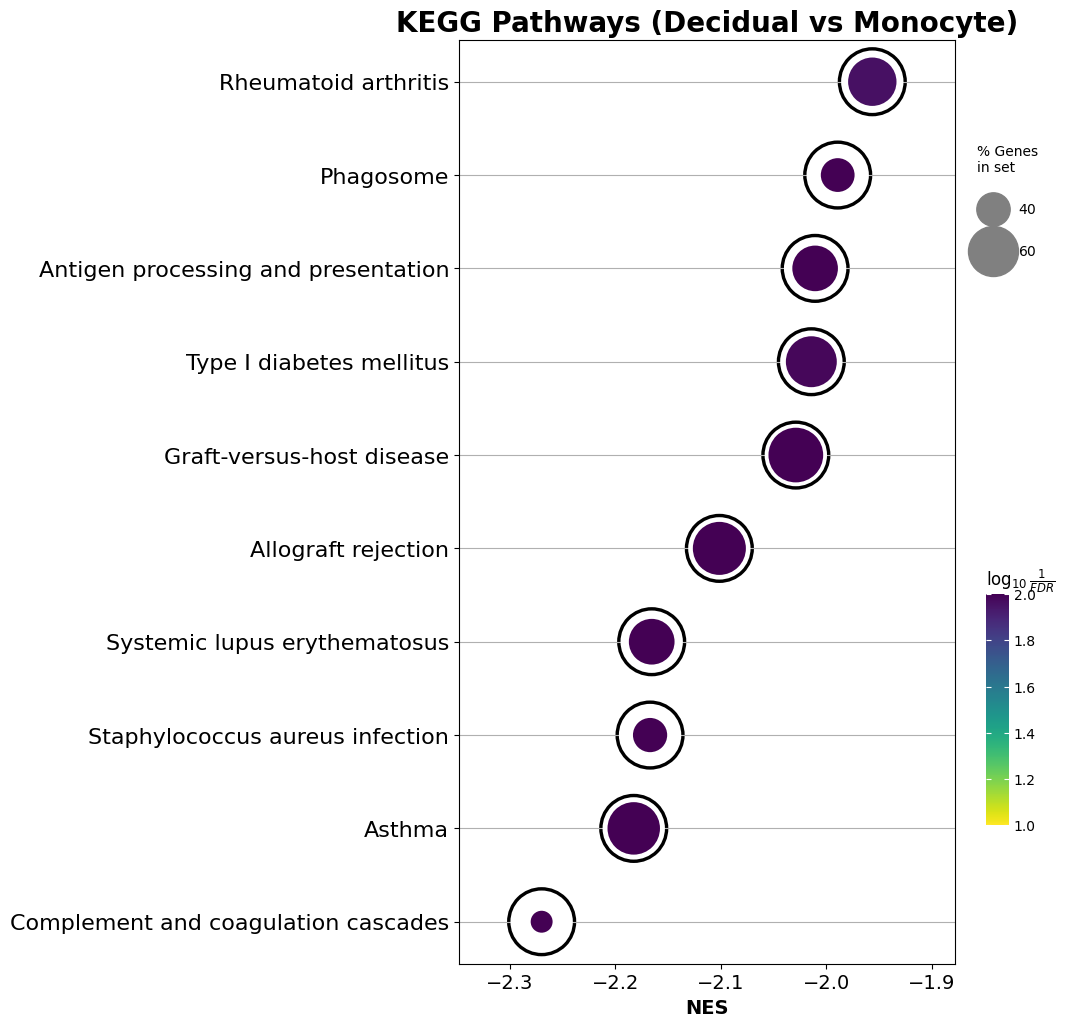

In [15]:
from gseapy import dotplot

# --- ESTRATEGIA A: Ver solo KEGG (Metabolismo y Señalización) ---
# Filtramos la tabla de resultados para quedarnos con los términos de KEGG
# (Nota: GSEApy a veces mezcla todo, así que lo más limpio es correr el plot específico)

# Corremos un GSEA rápido solo con KEGG para tener el gráfico limpio
res_kegg = gp.prerank(rnk=rnk,
                      gene_sets='KEGG_2021_Human',
                      threads=4,
                      min_size=15,
                      max_size=500,
                      permutation_num=1000,
                      seed=6)
# Graficamos KEGG
gp.dotplot(res_kegg.res2d,
           column="FDR q-val",  # <--- AGREGAR ESTA LÍNEA
           title='KEGG Pathways (Decidual vs Monocyte)',
           cmap='viridis_r',
           size=10,
           figsize=(8, 12),
           cutoff=0.25,
           show_ring=True)

plt.show()

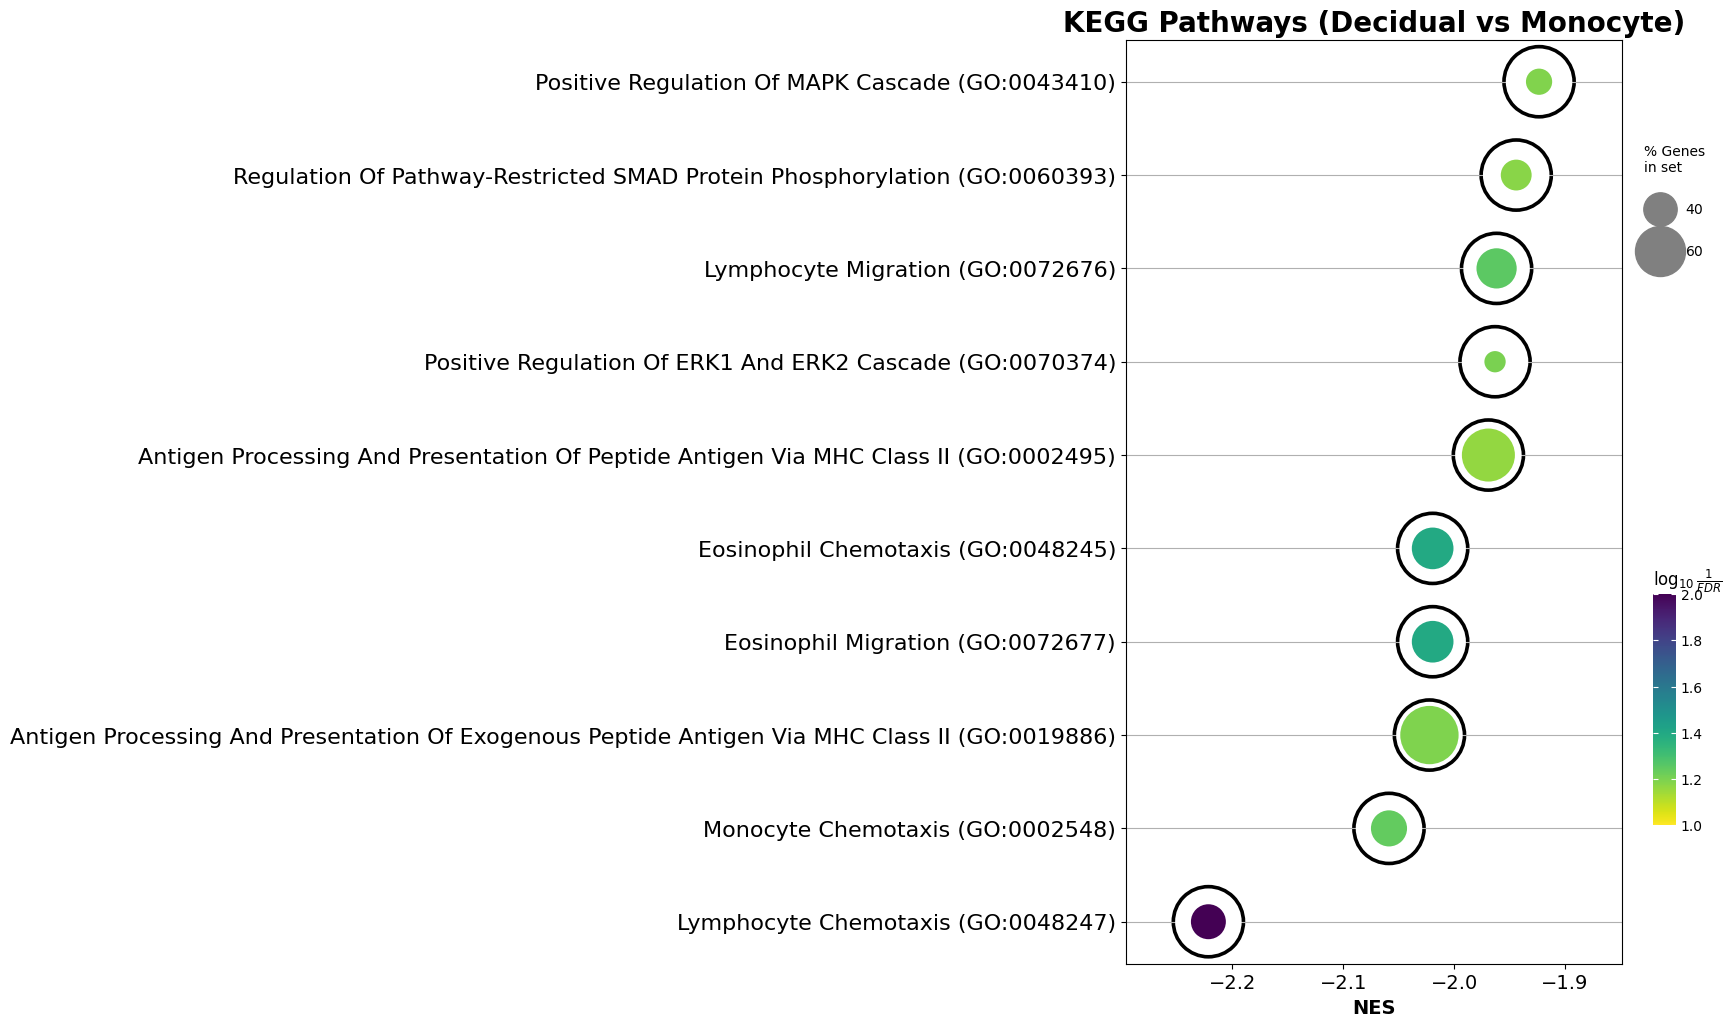

In [16]:
from gseapy import dotplot

# --- ESTRATEGIA A: Ver solo KEGG (Metabolismo y Señalización) ---
# Filtramos la tabla de resultados para quedarnos con los términos de KEGG
# (Nota: GSEApy a veces mezcla todo, así que lo más limpio es correr el plot específico)

# Corremos un GSEA rápido solo con KEGG para tener el gráfico limpio
res_kegg = gp.prerank(rnk=rnk,
                      gene_sets='GO_Biological_Process_2023',
                      threads=4,
                      min_size=15,
                      max_size=500,
                      permutation_num=1000,
                      seed=6)
# Graficamos KEGG
gp.dotplot(res_kegg.res2d,
           column="FDR q-val",  # <--- AGREGAR ESTA LÍNEA
           title='KEGG Pathways (Decidual vs Monocyte)',
           cmap='viridis_r',
           size=10,
           figsize=(8, 12),
           cutoff=0.25,
           show_ring=True)

plt.show()

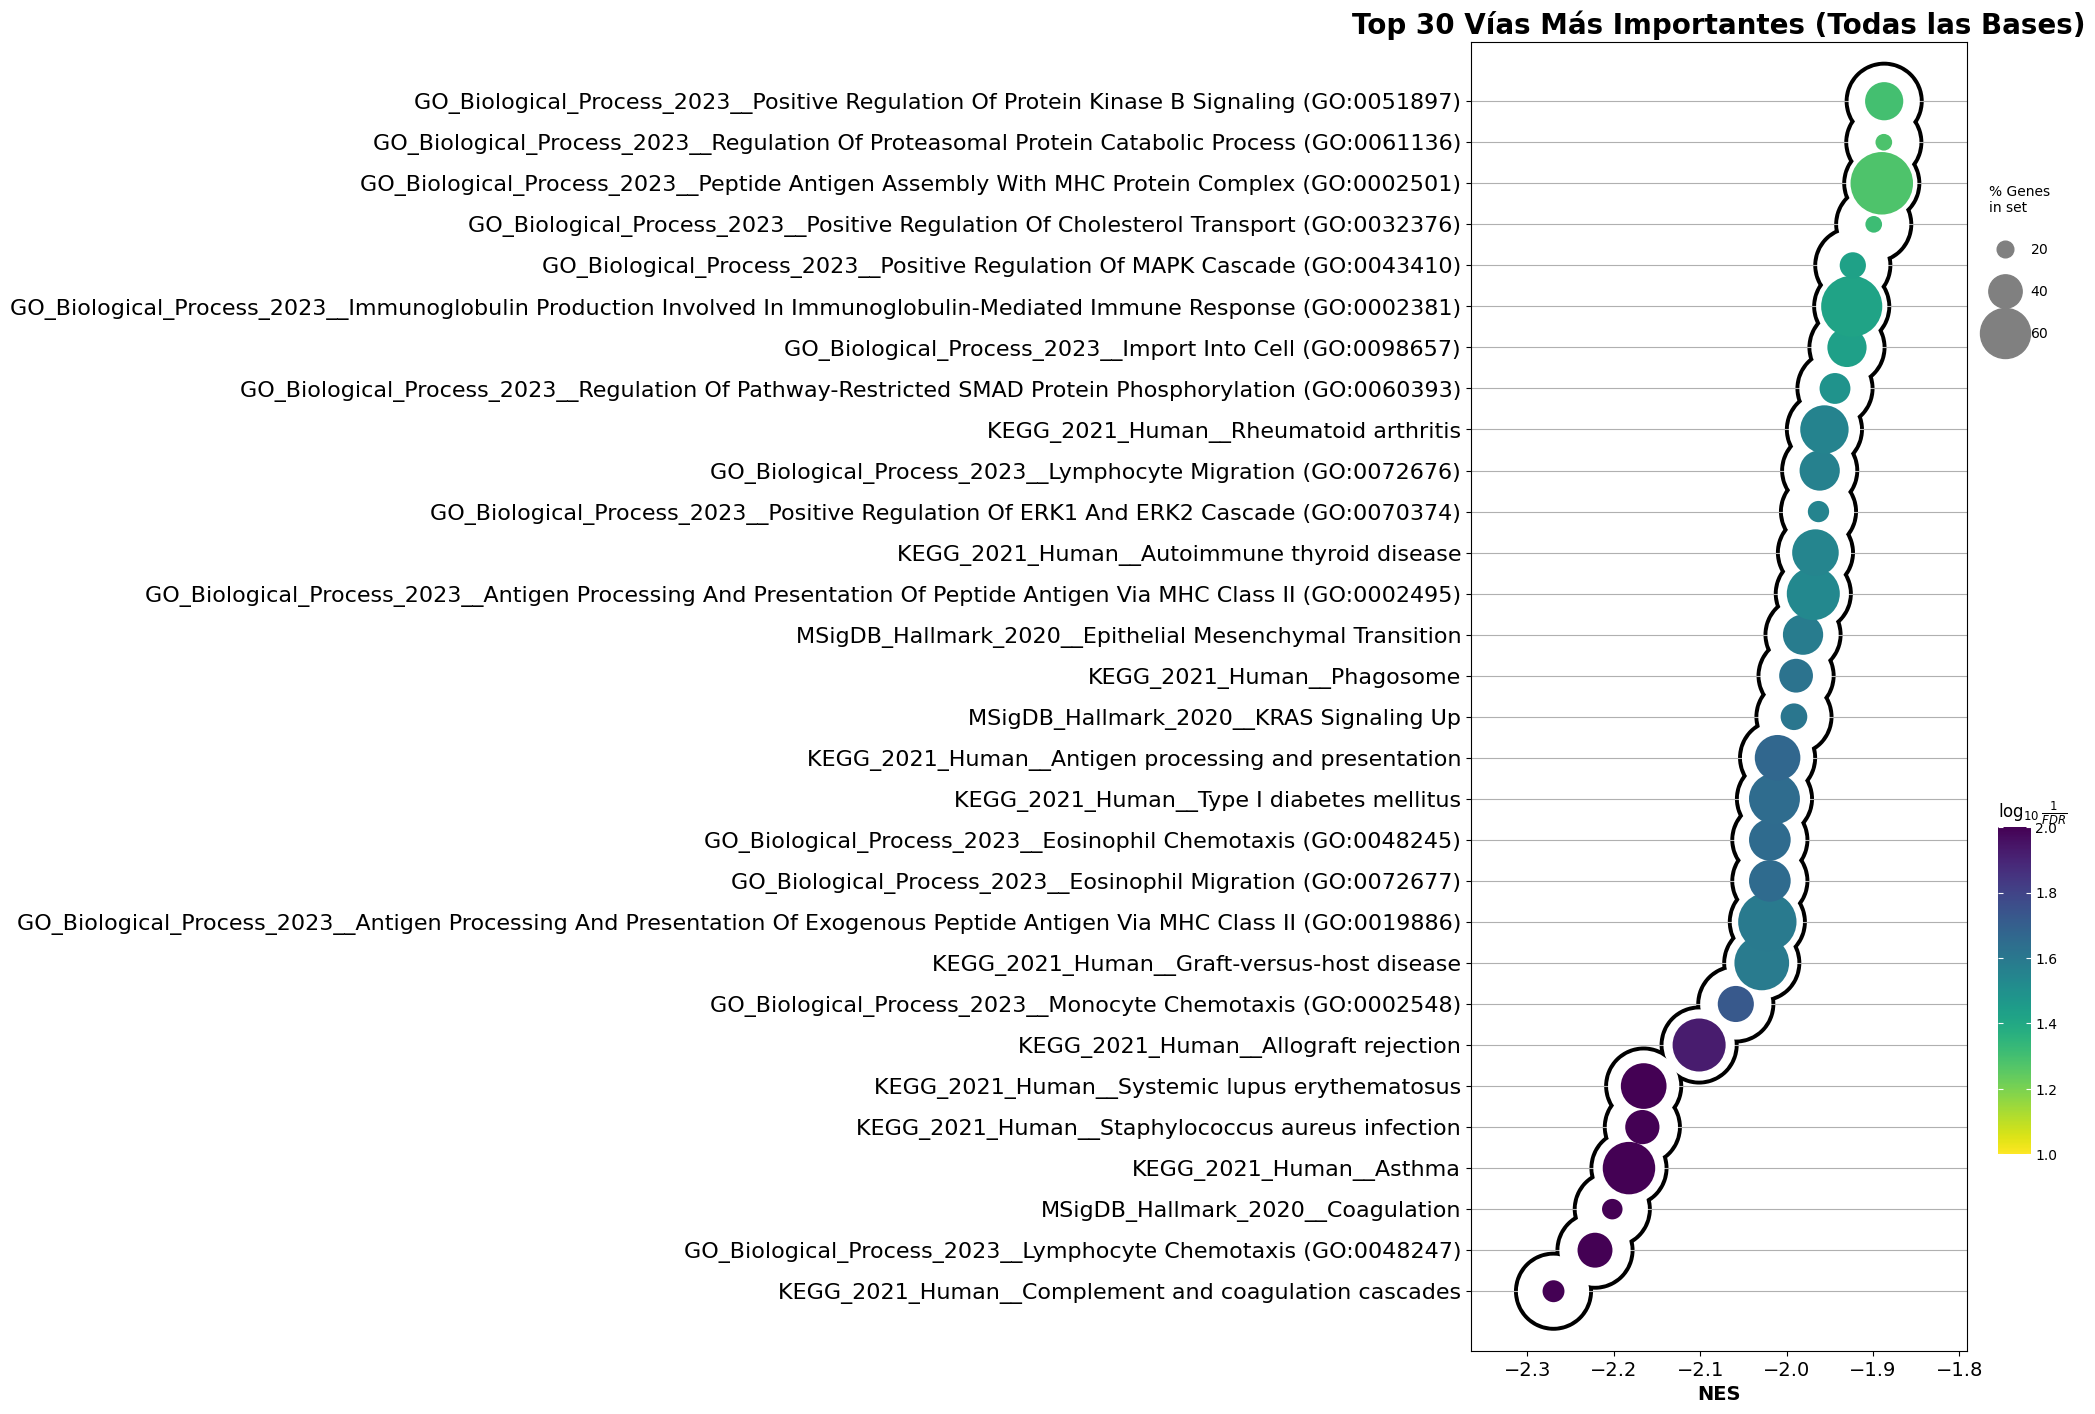

In [18]:

import pandas as pd
import gseapy as gp
import matplotlib.pyplot as plt

# --- PASO 1: Unificar todos los resultados ---
# Si corriste Hallmark/GO/KEGG en 'pre_res' y Reactome en 'res_reactome', los unimos.
# Si no corriste Reactome, borra ", res_reactome.res2d" de la lista.
frames = [pre_res.res2d]

# Descomenta la siguiente línea si tienes el objeto res_reactome creado
# frames.append(res_reactome.res2d)

all_results = pd.concat(frames)

# --- PASO 2: Configuración ---
NUM_VIAS = 30  # <--- ¡CAMBIA ESTE NÚMERO A TU GUSTO! (Ej. 15, 30, 50)

# --- PASO 3: Generar el Dotplot ---
ax = gp.dotplot(all_results,
                column="FDR q-val",     # Usamos la columna correcta
                title=f'Top {NUM_VIAS} Vías Más Importantes (Todas las Bases)',
                cmap='viridis_r',
                size=10,
                # Truco: Ajustamos la altura del gráfico según la cantidad de vías
                figsize=(8, NUM_VIAS * 0.5 + 2), 
                cutoff=0.25,            # Umbral de significancia visual
                show_ring=True,
                top_term=NUM_VIAS)      # Aquí le decimos cuántas mostrar

plt.show()

Cantidad de vías positivas encontradas: 746

--- TOP 10 VÍAS ACTIVADAS EN DECIDUAL ---
                                                  Term       NES FDR q-val
68                      KEGG_2021_Human__RNA transport  1.716593  0.225548
56   GO_Biological_Process_2023__Translation (GO:00...  1.751785  0.232586
121  GO_Biological_Process_2023__Chromatin Organiza...  1.619002   0.24303
112  GO_Biological_Process_2023__Cytoplasmic Transl...  1.629898  0.246067
73   GO_Biological_Process_2023__Positive Regulatio...  1.701428  0.246144
125  GO_Biological_Process_2023__Positive Regulatio...  1.613726  0.247162
67   GO_Biological_Process_2023__Protein Autophosph...  1.720782  0.247735
115  GO_Biological_Process_2023__Positive Regulatio...   1.62507  0.247808
110  GO_Biological_Process_2023__Gene Expression (G...  1.632991  0.249852
118  GO_Biological_Process_2023__Peptidyl-Threonine...  1.620385  0.250258


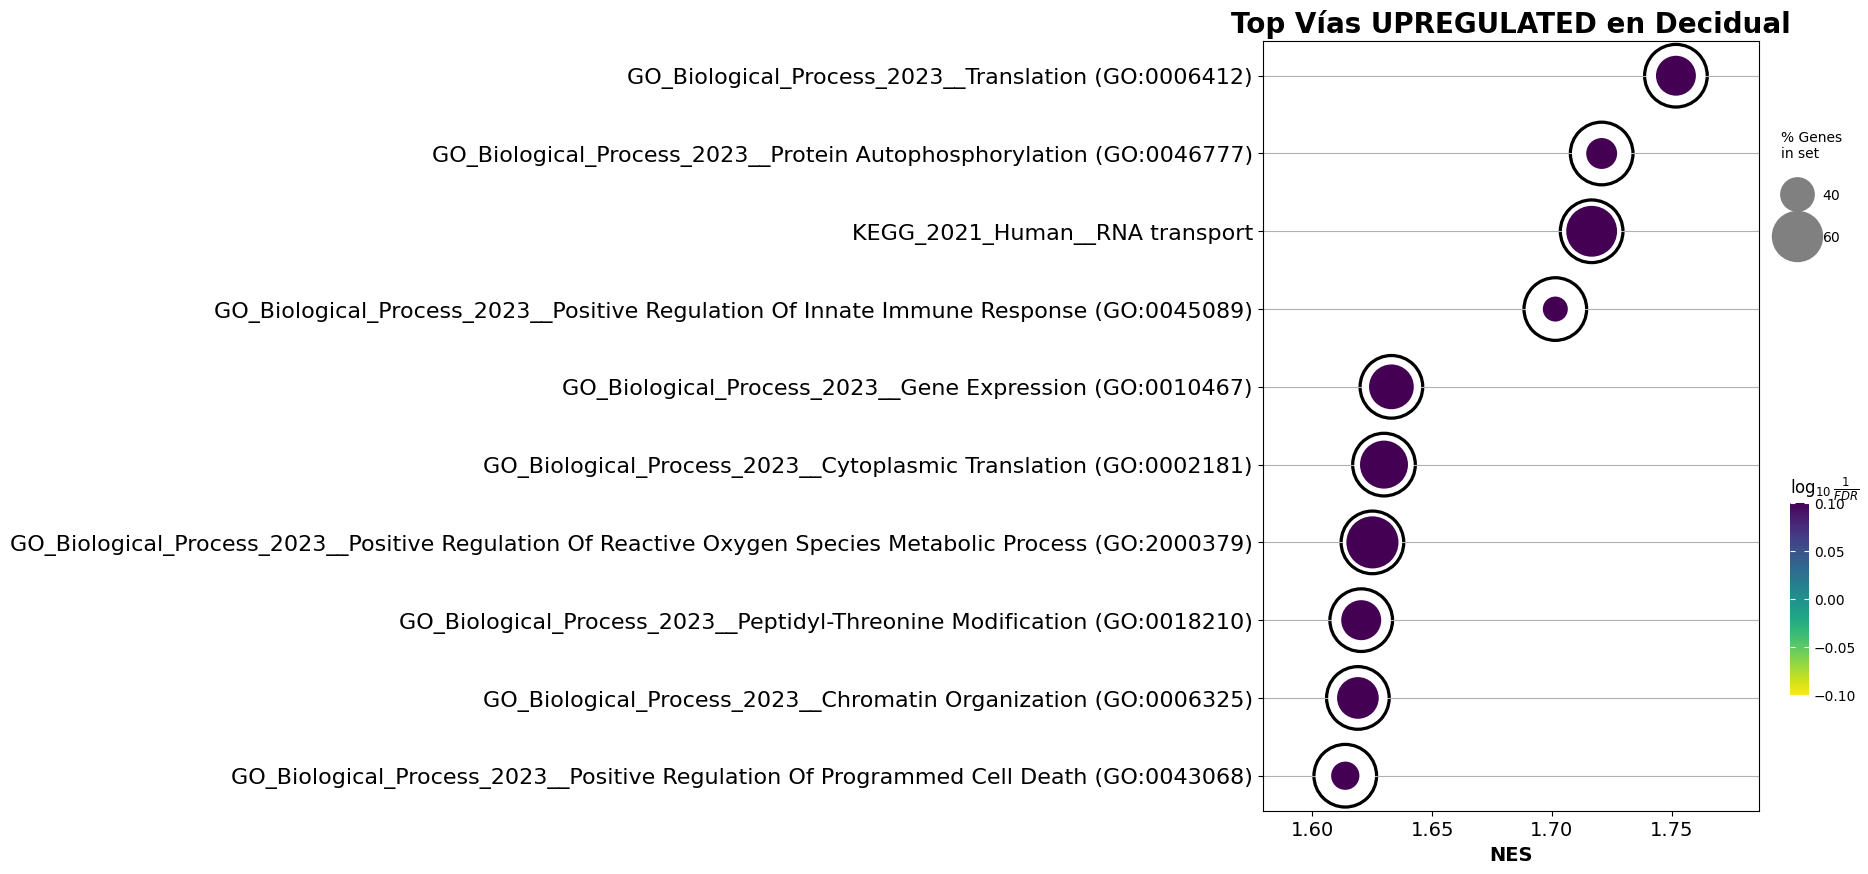

In [20]:

# 1. Filtramos solo las vías con NES Positivo (Enriquecidas en Decidual)
vias_positivas = all_results[all_results['NES'] > 0].sort_values(by='FDR q-val')

# 2. Vemos cuántas hay
print(f"Cantidad de vías positivas encontradas: {len(vias_positivas)}")

# 3. Mostramos las Top 10 positivas (si existen)
if len(vias_positivas) > 0:
    print("\n--- TOP 10 VÍAS ACTIVADAS EN DECIDUAL ---")
    print(vias_positivas[['Term', 'NES', 'FDR q-val']].head(10))
    
    # 4. Graficamos SOLO las positivas
    gp.dotplot(vias_positivas.head(20), # Mostramos las top 20 de las positivas
               column="FDR q-val",
               title='Top Vías UPREGULATED en Decidual',
               cmap='viridis_r',
               size=10,
               figsize=(8, 10),
               cutoff=1.0, # Ponemos 1.0 para que muestre todo aunque el FDR sea alto
               show_ring=True)
    plt.show()
else:
    print("No se encontraron vías con NES positivo. Revisa el orden de tu lista 'rnk'.")

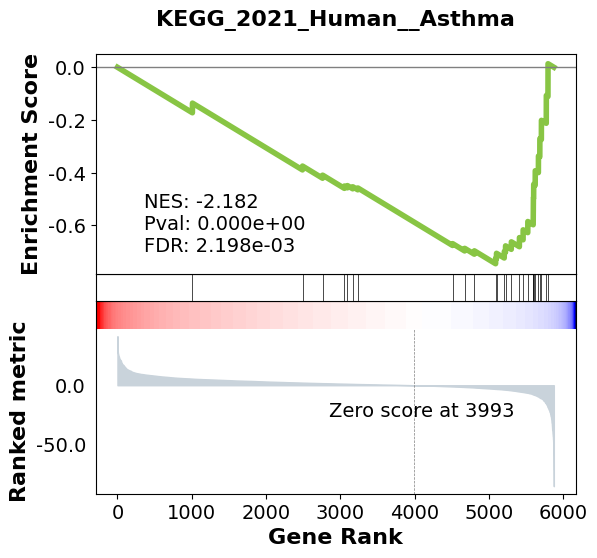

In [13]:
from gseapy import gseaplot

# Buscamos el nombre exacto del término en los resultados
# (Revisa pre_res.res2d.head() para ver los nombres exactos)
term_to_plot = "KEGG_2021_Human__Asthma" # <--- CAMBIA ESTO POR LA VÍA QUE TE GUSTE

# Generamos el gráfico
gseaplot(rank_metric=pre_res.ranking,
         term=term_to_plot,
         **pre_res.results[term_to_plot])

plt.show()